In [1]:
!pip install torchinfo
!pip install torchmetrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import os
# ------------------------ for the splitting of dataset ------------------------
import random
from pathlib import Path
# ------------------------for the lebling of dataset ------------------------
from torchvision import datasets, transforms
from torch.utils.data import DataLoader #turn the dataset into iterable and also for batching
from PIL import Image
from typing import List
# ------------------------ for the training of the model as MobileNetV2 ------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models  # ------------------ For MobileNetV2 ( or any pretrained model )
from sklearn.metrics import precision_score, recall_score, f1_score
# ------------------------ for plotting the curves ------------------------
import matplotlib.pyplot as plt
# ------------------------ for getting the summary of the model ------------------------
from torchinfo import summary

import json # To save metrics

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# walk through the dataset directory and print number of images in each subdirectory

def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")


# dataset_path = /content/drive/MyDrive/colon_after_splitting
# dataset_path = "/content/drive/MyDrive/COVID19+PNEUMONIA+NORMAL Chest X-Ray Image Dataset"
dataset_path = "/content/drive/MyDrive/K+F MRI (clean)"
walk_through_dir(dataset_path)  #& pass the dataset path here ...

There are 3 directories and 0 images in '/kaggle/input/f-k-mri-clean'
There are 2 directories and 0 images in '/kaggle/input/f-k-mri-clean/val'
There are 0 directories and 246 images in '/kaggle/input/f-k-mri-clean/val/No Tumor'
There are 0 directories and 246 images in '/kaggle/input/f-k-mri-clean/val/Tumor'
There are 2 directories and 0 images in '/kaggle/input/f-k-mri-clean/test'
There are 0 directories and 235 images in '/kaggle/input/f-k-mri-clean/test/No Tumor'
There are 0 directories and 235 images in '/kaggle/input/f-k-mri-clean/test/Tumor'
There are 2 directories and 0 images in '/kaggle/input/f-k-mri-clean/train'
There are 0 directories and 1400 images in '/kaggle/input/f-k-mri-clean/train/No Tumor'
There are 0 directories and 1400 images in '/kaggle/input/f-k-mri-clean/train/Tumor'


In [5]:
train_dir = os.path.join(dataset_path, "train")
val_dir   = os.path.join(dataset_path, "val")

In [6]:
## for colon cancer
# train_transform = transforms.Compose([

#     transforms.Resize (size = (224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], 
#                          std=[0.229, 0.224, 0.225]),

# ])

# val_transform = transforms.Compose([ #!No augmentation for validation !!!
#   transforms.Resize (size = (224, 224)),
#    transforms.ToTensor(),
#       transforms.Normalize(mean=[0.485, 0.456, 0.406],  
#                          std=[0.229, 0.224, 0.225]),

#  ])


In [7]:
# for the MRI & X-ray datasets
from PIL import Image

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),   # <--- ensures 3 channels always
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [8]:
train_dataset = datasets.ImageFolder(train_dir, transform = train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform = val_transform)

print("Original class mapping:", train_dataset.class_to_idx)
print("---------------------------------------------------------")
print (train_dataset)
print("=====================================================")
print (val_dataset)

Original class mapping: {'No Tumor': 0, 'Tumor': 1}
---------------------------------------------------------
Dataset ImageFolder
    Number of datapoints: 2800
    Root location: /kaggle/input/f-k-mri-clean/train
    StandardTransform
Transform: Compose(
               Lambda()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 492
    Root location: /kaggle/input/f-k-mri-clean/val
    StandardTransform
Transform: Compose(
               Lambda()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [9]:
print("traine dataset classes     :", train_dataset.class_to_idx, "| number of samples:", len(train_dataset))
print("validation dataset classes :", val_dataset.class_to_idx, "| number of samples:", len(val_dataset))

traine dataset classes     : {'No Tumor': 0, 'Tumor': 1} | number of samples: 2800
validation dataset classes : {'No Tumor': 0, 'Tumor': 1} | number of samples: 492


In [10]:
batch_size = 32
n_workers = 0

train_loader = DataLoader(train_dataset,batch_size=batch_size, shuffle=True, num_workers = n_workers) #----- Training: “Mix it up so the model learns broadly.”
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print("============================================")

print(f"length of train_loader : {len(train_loader)} batches of  {batch_size}")
print(f"length of val_loader   : {len(val_loader)} batches of  {batch_size}")

Number of training samples: 2800
Number of validation samples: 492
length of train_loader : 88 batches of  32
length of val_loader   : 16 batches of  32


In [11]:
print("traine dataset classes     :", train_dataset.class_to_idx, "| number of samples:", len(train_dataset))
print("validation dataset classes :", val_dataset.class_to_idx, "| number of samples:", len(val_dataset))

traine dataset classes     : {'No Tumor': 0, 'Tumor': 1} | number of samples: 2800
validation dataset classes : {'No Tumor': 0, 'Tumor': 1} | number of samples: 492


In [13]:
import torch
import torch.nn as nn
from torchvision import models

num_classes = 1

model = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)  # ⭐ recommended

for param in model.parameters():
    param.requires_grad = False

last_stage = model.trunk_output[-2]
for param in last_stage[-1].parameters():
    param.requires_grad = True

FEATURE_DIM = model.fc.in_features  # auto-detect
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(FEATURE_DIM, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, num_classes)
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [14]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)
# print what is trainable

trunk_output.block3.block3-7.f.a.0.weight
trunk_output.block3.block3-7.f.a.1.weight
trunk_output.block3.block3-7.f.a.1.bias
trunk_output.block3.block3-7.f.b.0.weight
trunk_output.block3.block3-7.f.b.1.weight
trunk_output.block3.block3-7.f.b.1.bias
trunk_output.block3.block3-7.f.se.fc1.weight
trunk_output.block3.block3-7.f.se.fc1.bias
trunk_output.block3.block3-7.f.se.fc2.weight
trunk_output.block3.block3-7.f.se.fc2.bias
trunk_output.block3.block3-7.f.c.0.weight
trunk_output.block3.block3-7.f.c.1.weight
trunk_output.block3.block3-7.f.c.1.bias
fc.1.weight
fc.1.bias
fc.4.weight
fc.4.bias


In [15]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
RegNet                                                  [1, 1]                    --
├─SimpleStemIN: 1-1                                     [1, 32, 112, 112]         --
│    └─Conv2d: 2-1                                      [1, 32, 112, 112]         (864)
│    └─BatchNorm2d: 2-2                                 [1, 32, 112, 112]         (64)
│    └─ReLU: 2-3                                        [1, 32, 112, 112]         --
├─Sequential: 1-2                                       [1, 784, 7, 7]            --
│    └─AnyStage: 2-4                                    [1, 64, 56, 56]           --
│    │    └─ResBottleneckBlock: 3-1                     [1, 64, 56, 56]           (19,016)
│    └─AnyStage: 2-5                                    [1, 144, 28, 28]          --
│    │    └─ResBottleneckBlock: 3-2                     [1, 144, 28, 28]          (65,824)
│    │    └─ResBottleneckBlock: 3-3        

In [16]:
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              ReLU-3         [-1, 32, 112, 112]               0
            Conv2d-4           [-1, 64, 56, 56]           2,048
       BatchNorm2d-5           [-1, 64, 56, 56]             128
            Conv2d-6         [-1, 64, 112, 112]           2,048
       BatchNorm2d-7         [-1, 64, 112, 112]             128
              ReLU-8         [-1, 64, 112, 112]               0
            Conv2d-9           [-1, 64, 56, 56]           9,216
      BatchNorm2d-10           [-1, 64, 56, 56]             128
             ReLU-11           [-1, 64, 56, 56]               0
AdaptiveAvgPool2d-12             [-1, 64, 1, 1]               0
           Conv2d-13              [-1, 8, 1, 1]             520
             ReLU-14              [-1, 

In [18]:
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [20]:
from timeit import default_timer as timer
def print_train_time (start : float,
                      end : float,
                      device : torch.device = None):

    """ print diffrence between start and end time. """

    total_time = end - start
    print(f"Total training time on {device}: {total_time:.3f} seconds")
    return total_time


#* calculating time it takes to train the model

In [21]:
dummy_input = torch.randn(4, 3, 224, 224).to(device)
print(model(dummy_input).shape)  # Should be: torch.Size([4, 1]) to indecate binary classification

torch.Size([4, 1])


In [22]:
print("Original class mapping:", train_dataset.class_to_idx)

Original class mapping: {'No Tumor': 0, 'Tumor': 1}


In [23]:
from tqdm.auto import tqdm  # for progress bar

torch.manual_seed(42)
start_time = timer() # start timing
pos = 1 # colon: 0, X-ray / MRI: 1
num_epochs = 20

#?---------------------------- save metrics ----------------------------
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_precisions, train_recalls, train_f1s = [], [], []
val_precisions, val_recalls, val_f1s = [], [], []
#%---------------------------- Training Loop ----------------------------
for epoch in range(num_epochs):
    model.train() #$the model use the batchnorm and dropout layers

    running_loss, correct, total = 0.0, 0, 0

    all_labels, all_preds = [], []


    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)

#----------------------- train step -----------------------
        outputs = model(inputs) # &----------------------- forward pass

        labels = labels.float().unsqueeze(1)
        loss = criterion(outputs, labels) #& ------------- compute the loss (predicytions vs true labels

        optimizer.zero_grad() #& --------------------------clear the gradients, set it to zero so it start fresh for this batch/ loop
        loss.backward() #& ------------------------------- backward pass
        optimizer.step() #& ------------------------------update the weights

    #= collect loss & metrics

        probs = torch.sigmoid(outputs) #convert logits to probabilities
        predicted = (probs > 0.5).long()   #convert probabilities to binary

        running_loss += loss.item() * inputs.size(0)
        correct += (predicted == labels.long()).sum().item()
        total += labels.size(0)

#?----------------------- collect the predictions and true labels

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy()) #collect true lebles and prediction across all batches

#*----------------------- compute metrics for training (storing them in the lists) -----------------------
    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total
    train_precision = precision_score(all_labels, all_preds, average='binary', pos_label=pos)
    train_recall = recall_score(all_labels, all_preds, average='binary', pos_label=pos)
    train_f1 = f1_score(all_labels, all_preds, average='binary', pos_label=pos)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)

    #$ --------------------------------------------- Validation Loop ---------------------------------------------
    model.eval() #$---------------------------- note : the model.eval disable dropout and batchnorm layers
    val_running_loss, val_correct, val_total = 0.0,0 ,0
    val_labels_all, val_preds_all = [], []

    with torch.no_grad():

        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)


            #only calculate the forward pass and the loss for the validation set

            outputs = model(inputs)

            labels = labels.float().unsqueeze(1)  # shape [B,1], Adds a new dimension of size 1, to model outputs,which usually are [batch_size, 1] for binary classification.
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).long()

            val_running_loss += loss.item() * inputs.size(0)
            val_correct += (predicted == labels.long()).sum().item()
            val_total += labels.size(0)

            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_correct / val_total
    val_precision = precision_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)
    val_recall = recall_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)
    val_f1 = f1_score(val_labels_all, val_preds_all, average='binary', pos_label=pos)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

       # Save metrics after each epoch
    metrics = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "train_precisions": train_precisions,
        "train_recalls": train_recalls,
        "train_f1s": train_f1s,
        "val_precisions": val_precisions,
        "val_recalls": val_recalls,
        "val_f1s": val_f1s,
    }
    with open("training_metrics_RegNet_X-ray.json", "w") as f:
        json.dump(metrics, f)



#*---------------------------- Print epoch metrics ----------------------------
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.5f}, Acc: {train_acc*100:.2f}%, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.5f}, Acc: {val_acc*100:.2f}%, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print("-----------------------------------------------------------")

end_time = timer() # end timing
training_time = print_train_time(start_time,end_time, device)

Epoch 1/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/20
Train Loss: 0.57621, Acc: 75.18%, Precision: 0.7282, Recall: 0.8036, F1: 0.7640
Val   Loss: 0.36292, Acc: 97.36%, Precision: 0.9641, Recall: 0.9837, F1: 0.9738
-----------------------------------------------------------


Epoch 2/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 19/20
Train Loss: 0.00842, Acc: 99.79%, Precision: 0.9986, Recall: 0.9971, F1: 0.9979
Val   Loss: 0.00868, Acc: 99.59%, Precision: 0.9919, Recall: 1.0000, F1: 0.9960
-----------------------------------------------------------


Epoch 20/20 [Train]:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 0.00945, Acc: 99.61%, Precision: 0.9957, Recall: 0.9964, F1: 0.9961
Val   Loss: 0.00578, Acc: 99.80%, Precision: 0.9960, Recall: 1.0000, F1: 0.9980
-----------------------------------------------------------
Total training time on cuda: 338.908 seconds


In [24]:
with open("training_metrics_RegNet_X-ray.json", "r") as f:
    metrics = json.load(f)

train_losses = metrics["train_losses"]
val_losses = metrics["val_losses"]


In [34]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['No Tumor', 'Tumor']


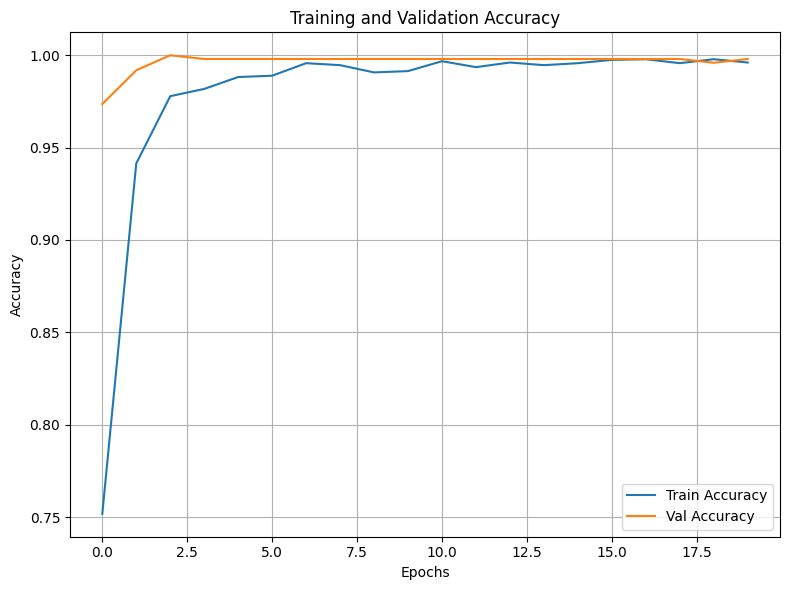

In [36]:
plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/Accuracy_RegNetY-800MF_MRI_M1.png")

plt.show()

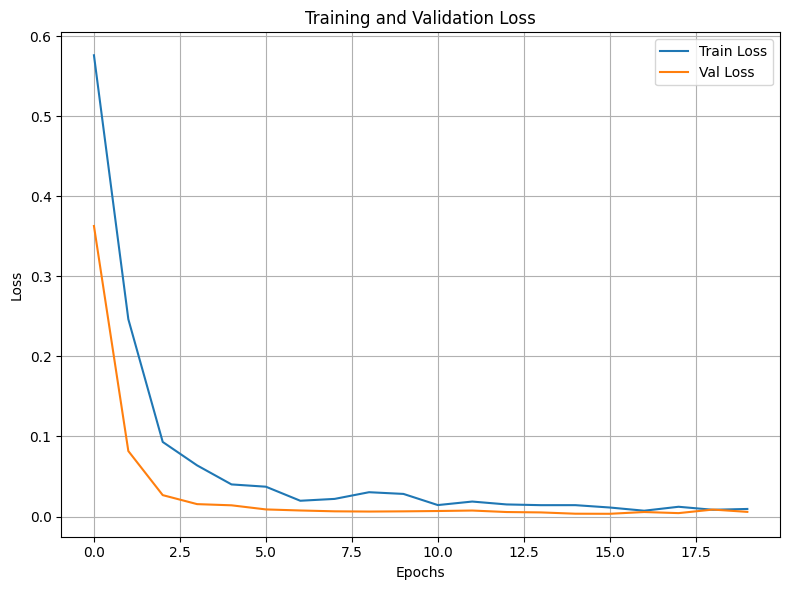

In [37]:
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/Loss_RegNetY-800MF_MRI_M1.png")

plt.show()

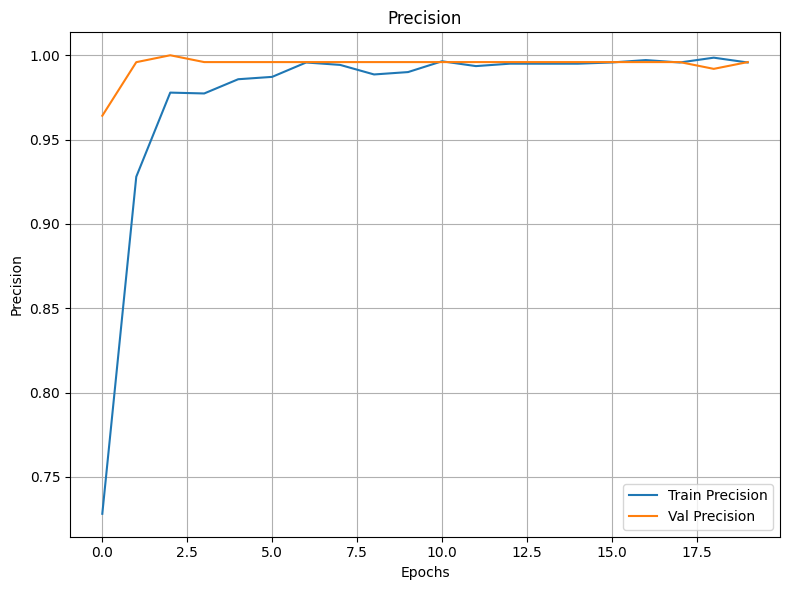

In [38]:
plt.figure(figsize=(8,6))
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Val Precision")
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Precision')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/Precision_RegNetY-800MF_MRI_M1.png")

plt.show()

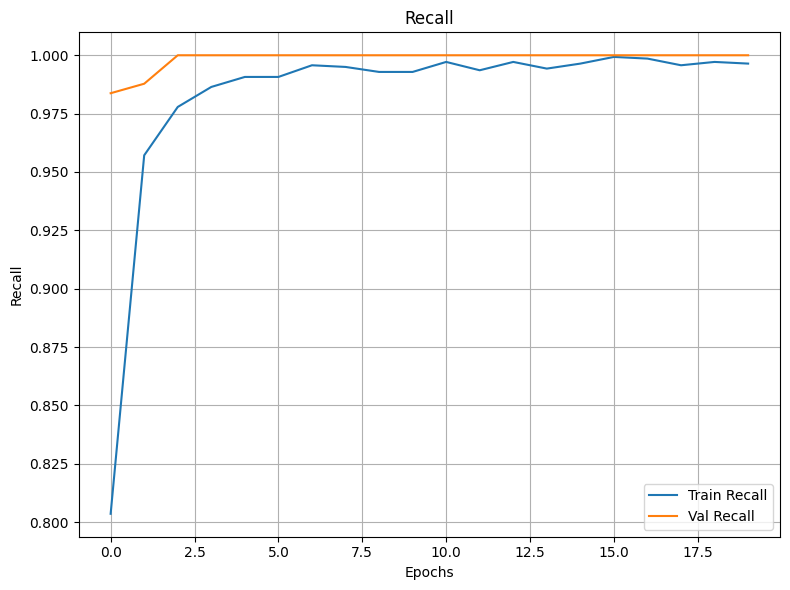

In [39]:
plt.figure(figsize=(8,6))
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Val Recall")
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/Recall_RegNetY-800MF_MRI_M1.png")

plt.show()

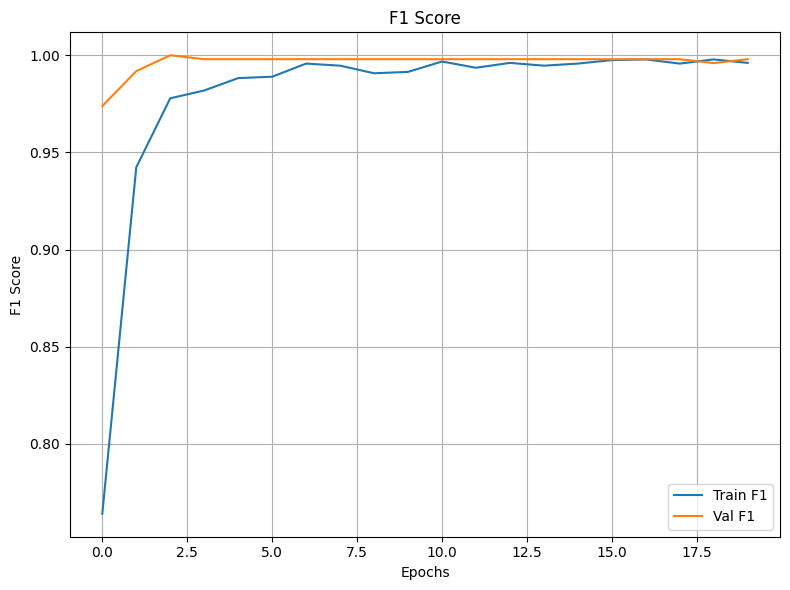

In [40]:
plt.figure(figsize=(8,6))
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/kaggle/working/F1-score_RegNetY-800MF_MRI_M1.png")

plt.show()

In [41]:
save_path_state_dict = "RegNetY-800MF_state_dict_MRI_M1.pth"
save_path_entire_model = "RegNetY-800MF_entire_MRI_M1.pth"

torch.save(model.state_dict(), save_path_state_dict)
print(f"Model state dictionary saved to {save_path_state_dict}")


torch.save(model, save_path_entire_model)
print(f"Entire model saved to {save_path_entire_model}")

Model state dictionary saved to RegNetY-800MF_state_dict_MRI_M1.pth
Entire model saved to RegNetY-800MF_entire_MRI_M1.pth
